# 01 - Data Exploration

Raw and processed data for the vegetable price forecasting project: prices (2000-2025), diesel fuel prices (2015-2025), and district-wise weather (2013-2026). This notebook is exploratory only - production logic lives in `src/`, per CLAUDE.md.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.io import load_config

config = load_config()
config['vegetables']

['carrot', 'brinjal', 'pumpkin', 'cabbage', 'snake_gourd', 'leeks']

## Raw sources

In [2]:
prices = pd.read_csv('../data/raw/vegetable_prices/vegetable_prices.csv', parse_dates=['week_start'])
fuel = pd.read_csv('../data/raw/fuel/fuel_data_weekly.csv', parse_dates=['date'])
weather = pd.read_csv('../data/raw/weather/weather.csv', parse_dates=['week_start_date'])

print(prices.shape, fuel.shape, weather.shape)
prices.head()

(8184, 4) (603, 2) (16400, 4)


,vegetable,week_start,wholesale_price,retail_price
0,BRINJALS,2000-01-03,19.20,40.00
1,CABBAGE,2000-01-03,14.67,35.79
2,CARROT,2000-01-03,37.67,57.21
3,LEEKS,2000-01-03,27.27,43.11
4,PUMPKIN,2000-01-03,7.07,25.49


## Retail price trend per vegetable

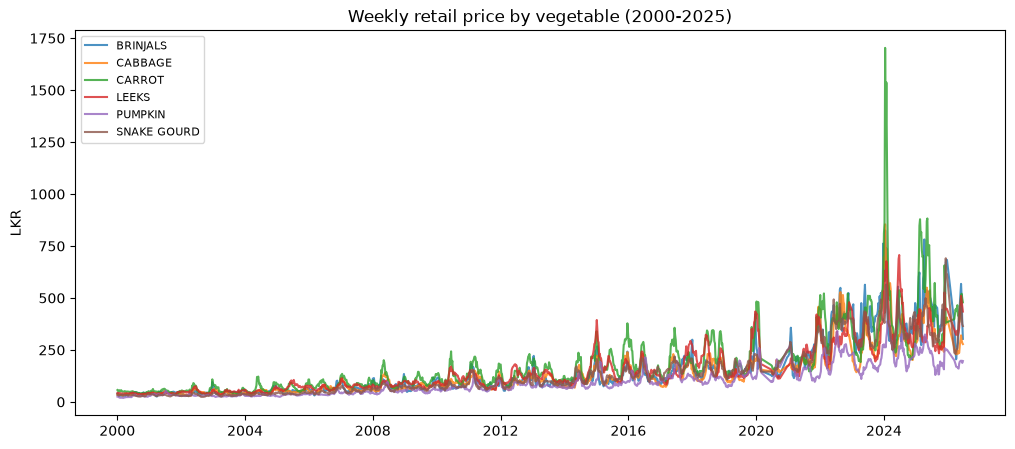

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
for veg, grp in prices.groupby('vegetable'):
    ax.plot(grp['week_start'], grp['retail_price'], label=veg, alpha=0.8)
ax.set_title('Weekly retail price by vegetable (2000-2025)')
ax.set_ylabel('LKR')
ax.legend(loc='upper left', fontsize=8)
plt.show()

## Fuel price trend

Diesel is the transport-cost driver used as an exogenous feature (petrol was dropped from the raw dataset - it isn't part of the vegetable supply chain).

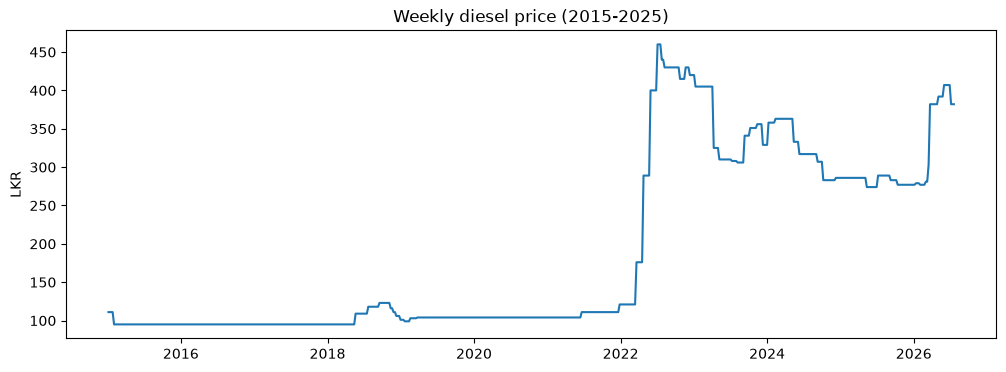

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fuel['date'], fuel['diesel_price'])
ax.set_title('Weekly diesel price (2015-2025)')
ax.set_ylabel('LKR')
plt.show()

## Weather: representative districts per the mapping in `configs/config.yaml`

Several vegetables share the same growing district (e.g. carrot/leeks/cabbage all map to Nuwara Eliya), so plotting one line *per vegetable* draws identical lines directly on top of each other and hides all but one. Grouping by district instead, with every vegetable that maps to it in the label, shows all 6 vegetables without any hidden overlap.

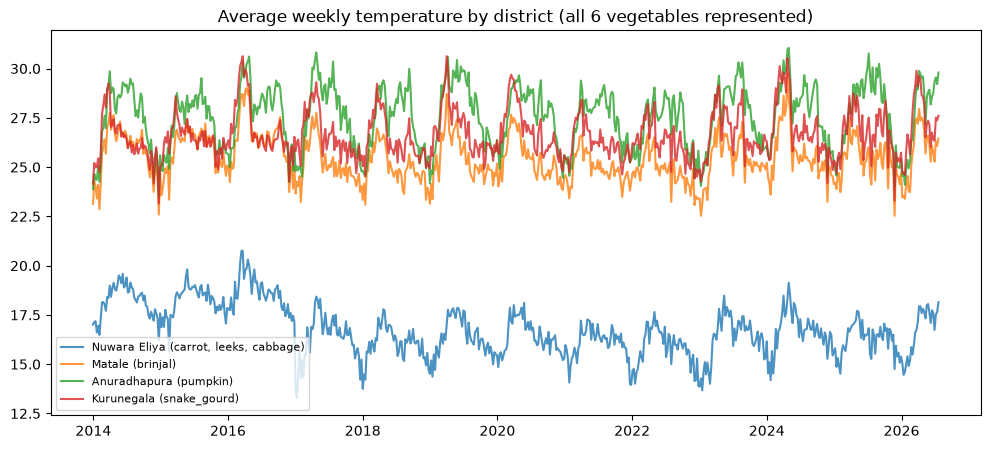

In [5]:
from collections import defaultdict

district_map = config['weather_district_map']
vegs_by_district = defaultdict(list)
for veg, district in district_map.items():
    vegs_by_district[district].append(veg)

fig, ax = plt.subplots(figsize=(12, 5))
for district, vegs in vegs_by_district.items():
    d = weather[weather['district'] == district]
    ax.plot(d['week_start_date'], d['average_temperature'], label=f"{district} ({', '.join(vegs)})", alpha=0.8)
ax.set_title('Average weekly temperature by district (all 6 vegetables represented)')
ax.legend(fontsize=8)
plt.show()

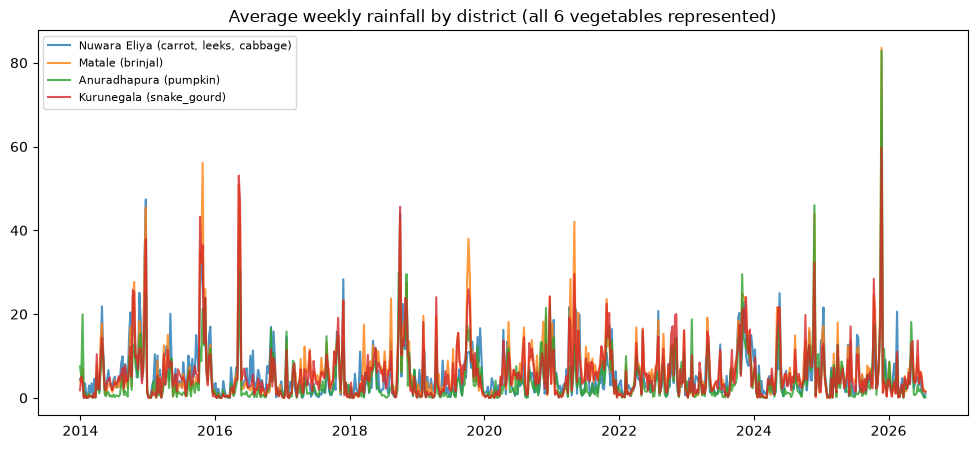

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
for district, vegs in vegs_by_district.items():
    d = weather[weather['district'] == district]
    ax.plot(d['week_start_date'], d['average_rainfall'], label=f"{district} ({', '.join(vegs)})", alpha=0.8)
ax.set_title('Average weekly rainfall by district (all 6 vegetables represented)')
ax.legend(fontsize=8)
plt.show()

## Processed per-vegetable datasets (after `build_dataset.py` merges all 3 sources)

In [7]:
carrot = pd.read_csv('../data/processed/carrot.csv', parse_dates=['date'])
carrot.describe()

,date,retail_price,wholesale_price,average_temperature,average_rainfall,diesel_price
count,583,583.000000,583.000000,583.000000,583.000000,583.000000
mean,2020-08-14 12:38:17.084048,290.386244,185.856594,16.674734,5.485986,185.140652
min,2015-01-05 00:00:00,94.047619,37.920000,13.290000,0.000000,95.000000
25%,2017-10-26 12:00:00,174.071212,97.777778,15.855000,1.690000,95.000000
50%,2020-08-10 00:00:00,238.666667,136.666667,16.560000,3.560000,104.000000
75%,2023-06-01 12:00:00,378.155909,240.500000,17.450000,6.960000,289.000000
max,2026-06-22 00:00:00,1703.333333,1395.833333,20.760000,66.040000,460.000000
std,NaN,174.082131,143.920577,1.249122,6.183800,117.112969


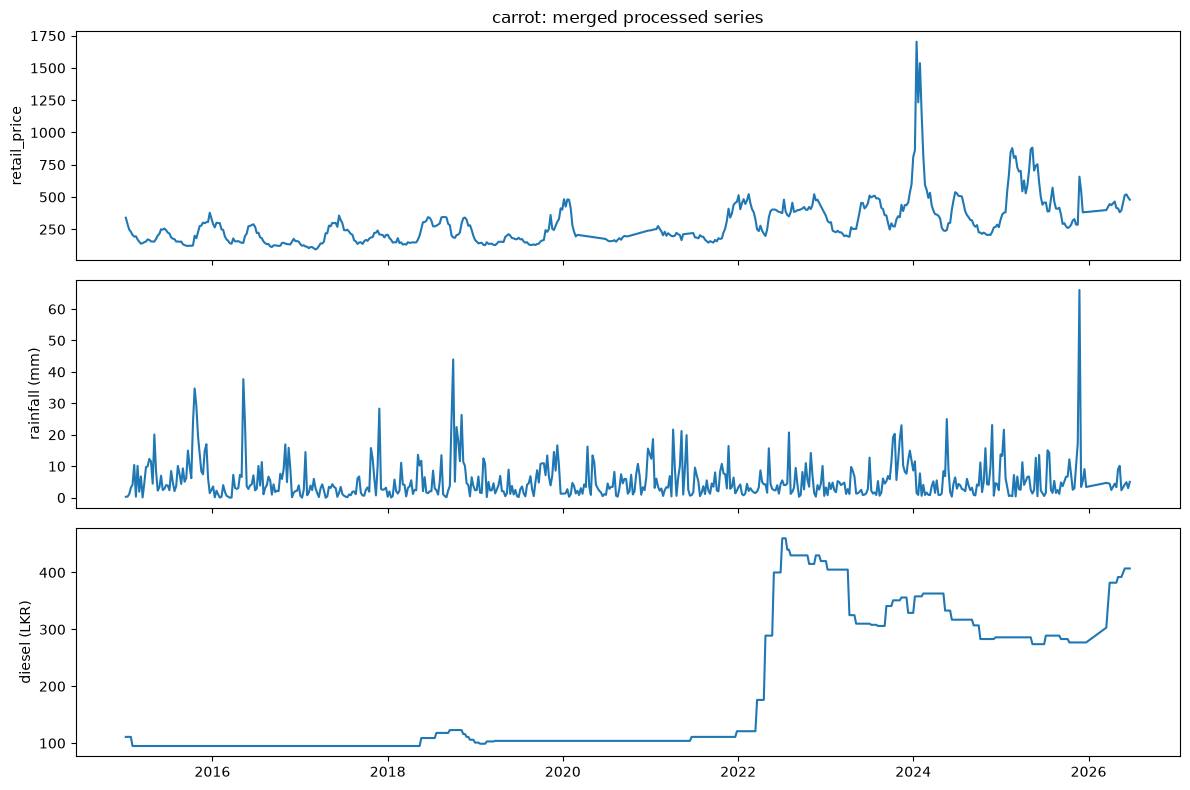

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(carrot['date'], carrot['retail_price']); axes[0].set_ylabel('retail_price')
axes[1].plot(carrot['date'], carrot['average_rainfall']); axes[1].set_ylabel('rainfall (mm)')
axes[2].plot(carrot['date'], carrot['diesel_price']); axes[2].set_ylabel('diesel (LKR)')
axes[0].set_title('carrot: merged processed series')
plt.tight_layout(); plt.show()

## Correlation between exogenous drivers and price

In [9]:
carrot[['retail_price', 'average_rainfall', 'average_temperature', 'diesel_price']].corr()

,retail_price,average_rainfall,average_temperature,diesel_price
retail_price,1.000000,-0.034906,-0.249615,0.572935
average_rainfall,-0.034906,1.000000,-0.000541,0.011368
average_temperature,-0.249615,-0.000541,1.000000,-0.205407
diesel_price,0.572935,0.011368,-0.205407,1.000000


---
# Pattern & Trend Analysis

The sections above show the raw series. This section characterizes *how* each vegetable's price behaves: trend/seasonality decomposition, whether volatility has changed over time (motivates why SARIMAX struggles on the recent holdout year - see CLAUDE.md), autocorrelation structure (motivates the SARIMAX order and the lag features in `feature_engineering.py`), and which exogenous lag actually correlates most with price.

## Seasonal decomposition (STL)

Decomposes each vegetable's retail price into trend, (52-week) seasonal, and residual components.

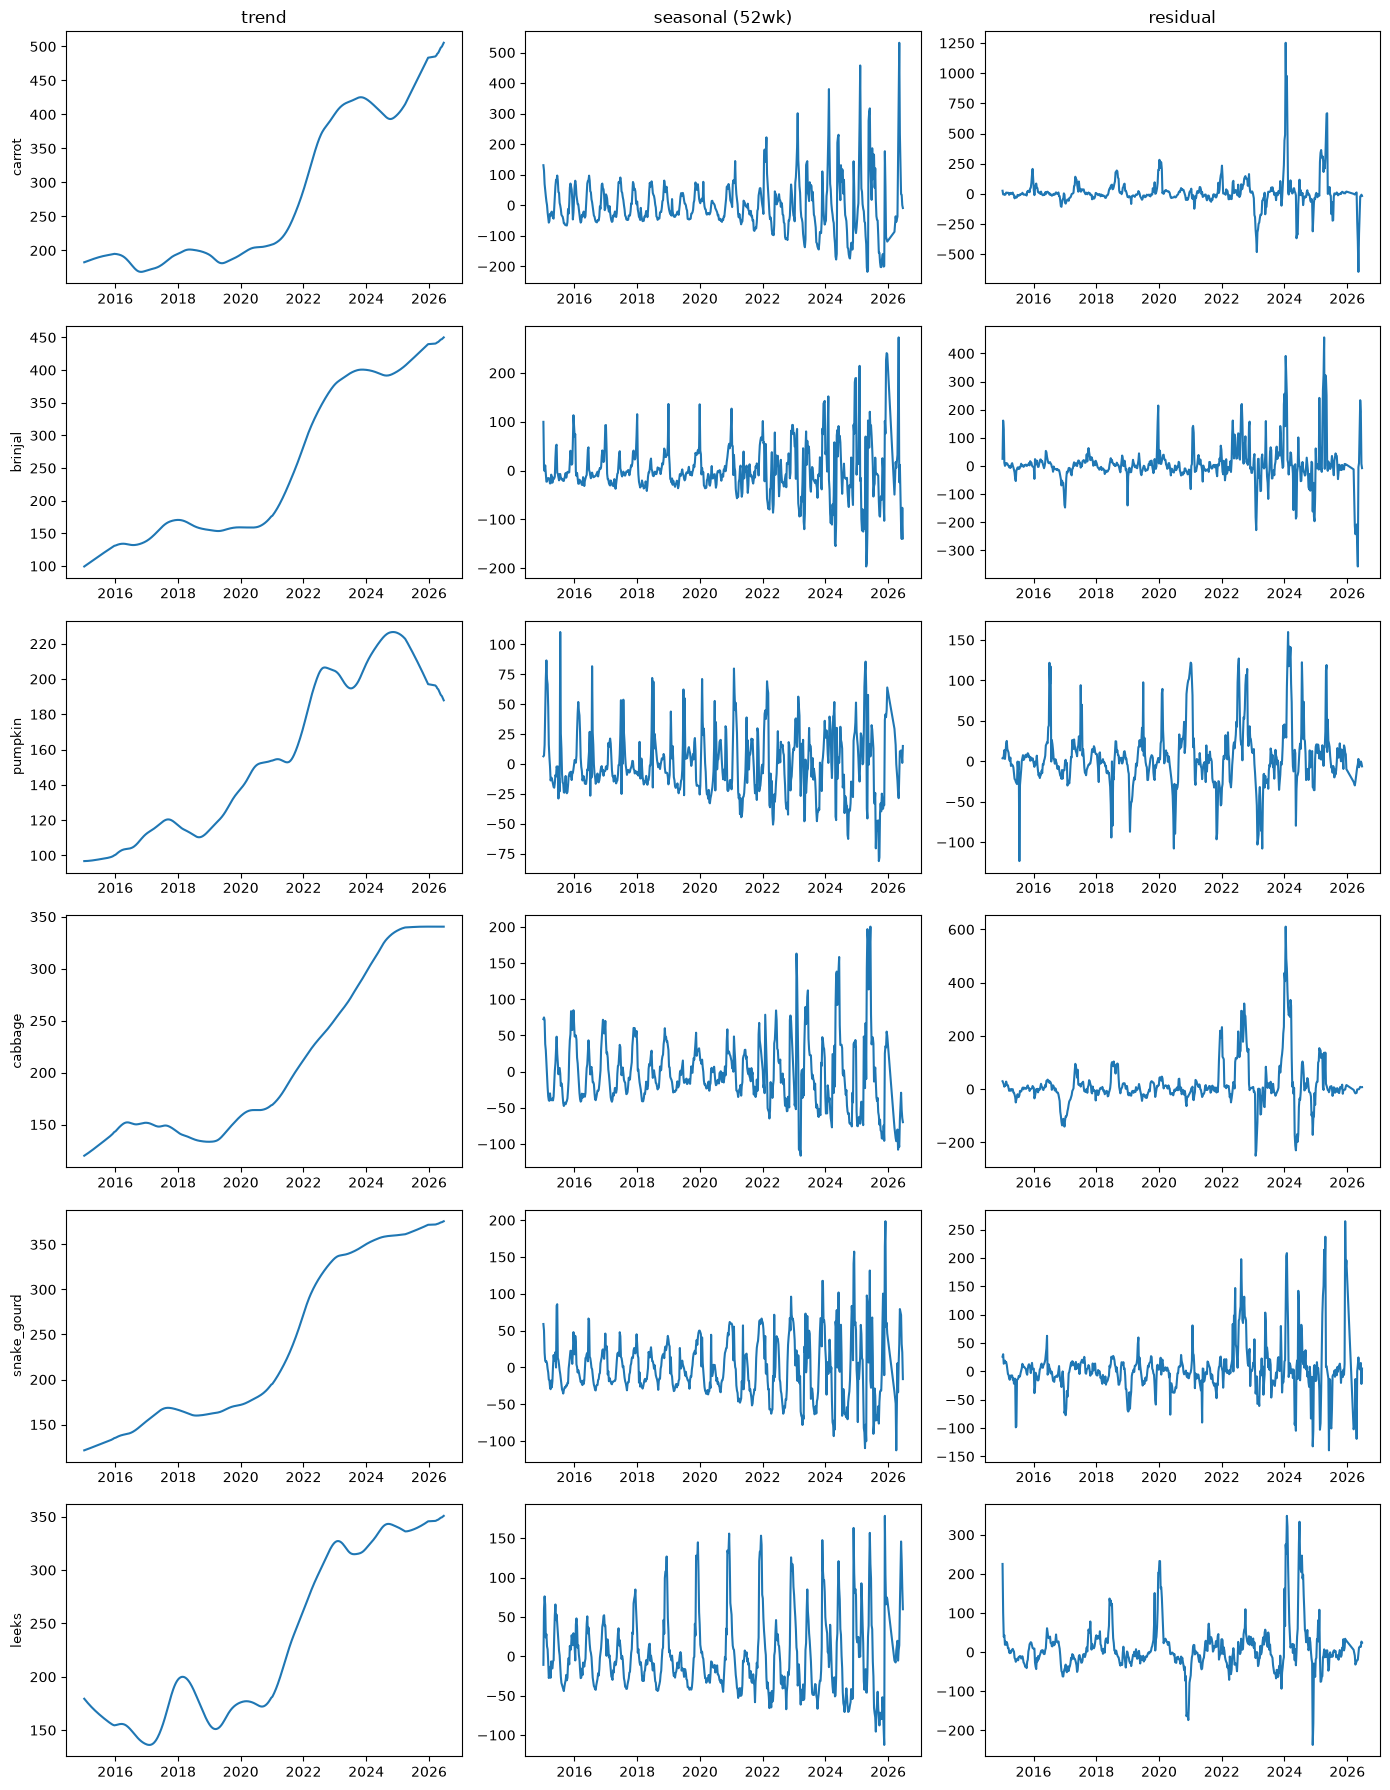

In [10]:
from statsmodels.tsa.seasonal import STL

vegetables = config['vegetables']
fig, axes = plt.subplots(len(vegetables), 3, figsize=(14, 3 * len(vegetables)))

for i, veg in enumerate(vegetables):
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date']).set_index('date')
    result = STL(df['retail_price'], period=52, robust=True).fit()
    axes[i, 0].plot(result.trend); axes[i, 0].set_ylabel(veg, fontsize=9)
    axes[i, 1].plot(result.seasonal)
    axes[i, 2].plot(result.resid)
    if i == 0:
        axes[i, 0].set_title('trend'); axes[i, 1].set_title('seasonal (52wk)'); axes[i, 2].set_title('residual')

plt.tight_layout(); plt.show()

## Year-over-year seasonality

Overlaying each calendar year's price curve (by week-of-year) shows whether the seasonal pattern is consistent, and which years were anomalous.

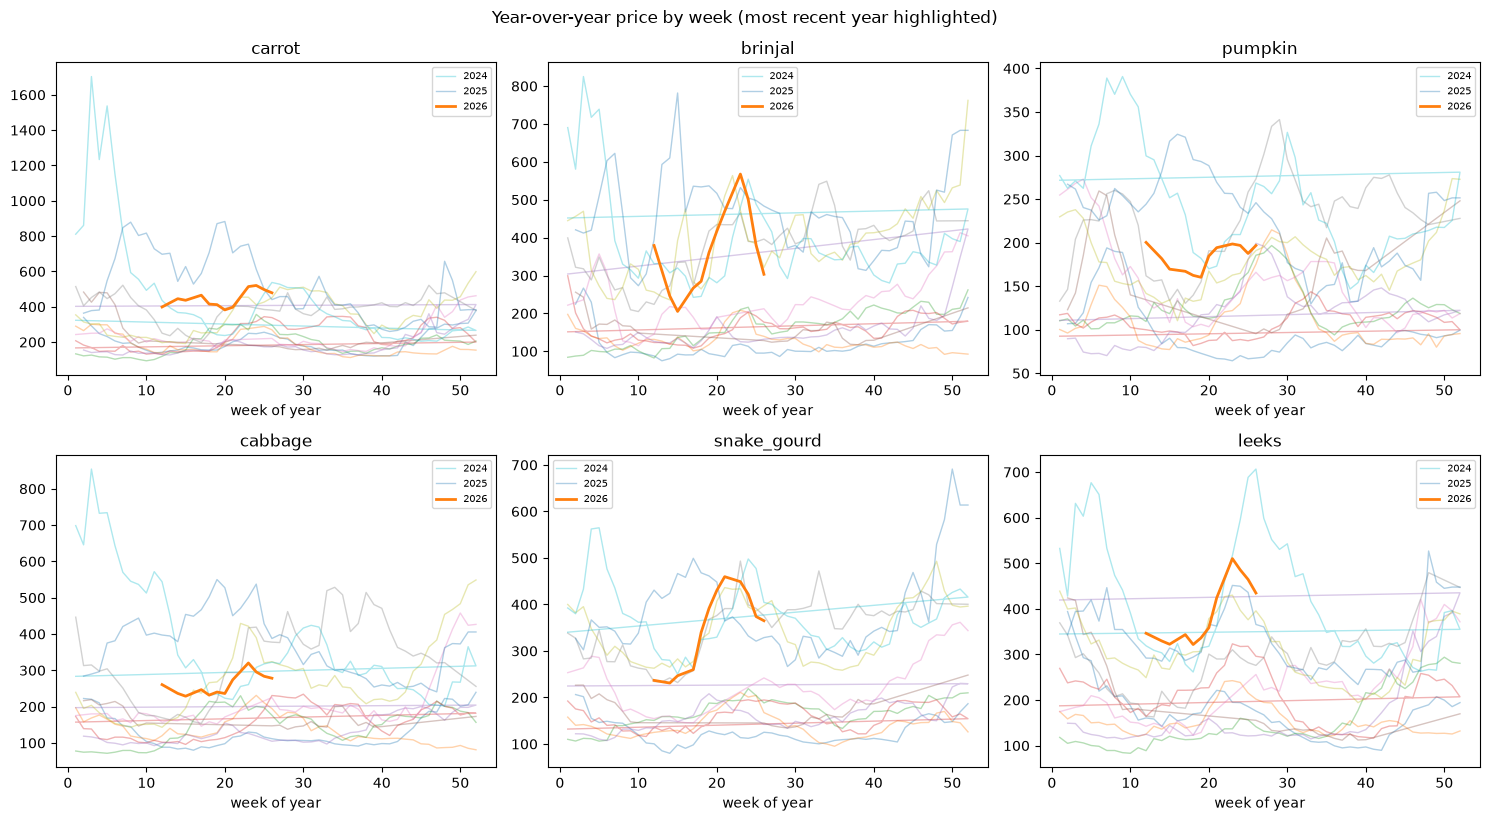

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, veg in zip(axes.flat, vegetables):
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date'])
    df['year'] = df['date'].dt.year
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    for year, grp in df.groupby('year'):
        alpha = 1.0 if year == df['year'].max() else 0.35
        lw = 2 if year == df['year'].max() else 1
        ax.plot(grp['week_of_year'], grp['retail_price'], alpha=alpha, linewidth=lw, label=str(year) if year >= 2024 else None)
    ax.set_title(veg); ax.set_xlabel('week of year')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.suptitle('Year-over-year price by week (most recent year highlighted)', y=1.02)
plt.show()

## Rolling volatility

12-week rolling standard deviation of retail price. A rising line means the market has gotten *more* volatile recently - directly relevant to why SARIMAX's holdout R² is negative on every vegetable (see CLAUDE.md's Project status).

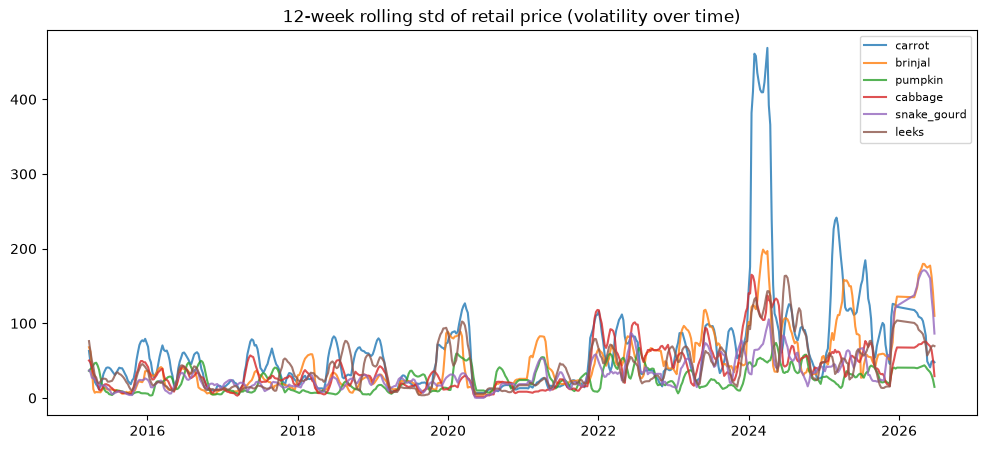

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for veg in vegetables:
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date'])
    rolling_std = df['retail_price'].rolling(12).std()
    ax.plot(df['date'], rolling_std, label=veg, alpha=0.8)
ax.set_title('12-week rolling std of retail price (volatility over time)')
ax.legend(fontsize=8)
plt.show()

## Autocorrelation (ACF/PACF)

On the differenced series (removing trend), for carrot - motivates the SARIMAX order in `configs/config.yaml` and the lag features in `feature_engineering.py`.

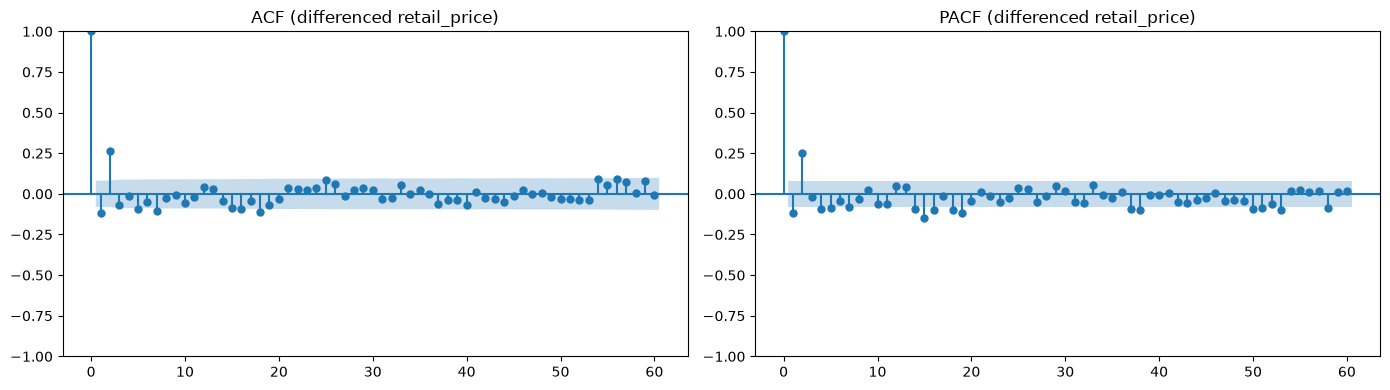

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

carrot_diff = carrot['retail_price'].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(carrot_diff, lags=60, ax=axes[0])
plot_pacf(carrot_diff, lags=60, ax=axes[1])
axes[0].set_title('ACF (differenced retail_price)')
axes[1].set_title('PACF (differenced retail_price)')
plt.tight_layout(); plt.show()

## Which exogenous lag correlates most with price?

Correlates retail price against rainfall/temperature/diesel at lags 0-8 weeks, per vegetable - tells us whether the 1-week lag used in `feature_engineering.py` is actually the strongest signal, or whether a longer lag would serve better.

In [14]:
lags = range(0, 9)
rows = []
for veg in vegetables:
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date'])
    for lag in lags:
        row = {'vegetable': veg, 'lag_weeks': lag}
        for driver in ['average_rainfall', 'average_temperature', 'diesel_price']:
            row[driver] = df['retail_price'].corr(df[driver].shift(lag))
        rows.append(row)
lag_corr = pd.DataFrame(rows)
best_lag = lag_corr.loc[lag_corr.groupby('vegetable')['diesel_price'].apply(lambda s: s.abs().idxmax())]
print('Strongest |correlation| lag for diesel_price, per vegetable:')
best_lag[['vegetable', 'lag_weeks', 'diesel_price']]

Strongest |correlation| lag for diesel_price, per vegetable:


,vegetable,lag_weeks,diesel_price
11,brinjal,2,0.790216
28,cabbage,1,0.702134
0,carrot,0,0.572935
53,leeks,8,0.704611
18,pumpkin,0,0.672482
37,snake_gourd,1,0.825777


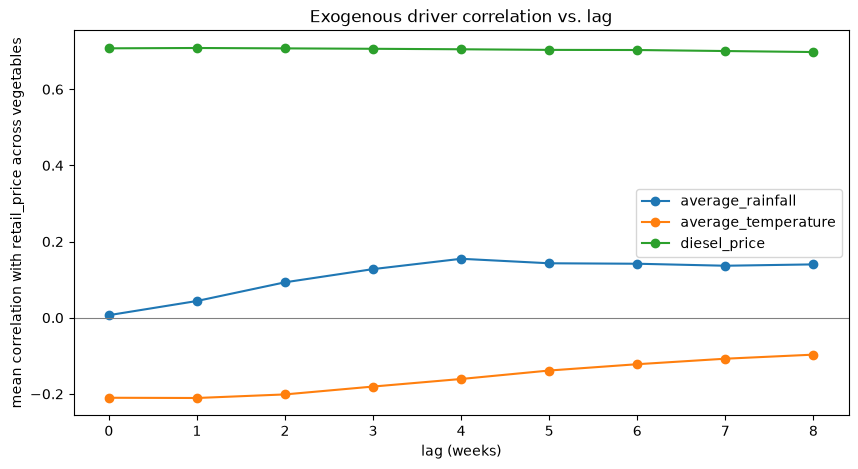

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
for driver in ['average_rainfall', 'average_temperature', 'diesel_price']:
    avg_by_lag = lag_corr.groupby('lag_weeks')[driver].mean()
    ax.plot(avg_by_lag.index, avg_by_lag.values, marker='o', label=driver)
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('lag (weeks)'); ax.set_ylabel('mean correlation with retail_price across vegetables')
ax.set_title('Exogenous driver correlation vs. lag')
ax.legend()
plt.show()